# Netective Properties Dataframe

### Imports

In [1]:
import pandas as pd
import inspect
import numpy as np
import seaborn as sb
from netective.structure.timed_structure import Structure
import networkx as nx


### Creación de Dataframe

#### Dummy network

In [2]:
net = nx.erdos_renyi_graph(100, 0.2, directed=True)

#### Creación de instancias

In [3]:
struct = Structure(G= net, norm= None, net_id= 'prueba', verbose= 'critical')
instances = struct.get_props(return_instances= True)
instances

{'Average Degree for Nearest Neighbors (Undirected)': <netective.structure.properties.AverageDegreeNearestNeighbors at 0x2482fcddd30>,
 'Clustering Coefficient': <netective.structure.properties.ClusteringCoefficient at 0x2482fcddf40>,
 'Rich Club Coefficient': <netective.structure.properties.RichClub at 0x2482fcddd90>,
 'Average Local Efficiency': <netective.structure.properties.AverageLocalEfficiency at 0x2482fcddac0>,
 'Average Shortest Path Length': <netective.structure.properties.AverageShortestPathLength at 0x2482fcddc10>,
 'Betweenness Centrality': <netective.structure.properties.BetweennessCentrality at 0x2482fcdd8e0>,
 'Center': <netective.structure.properties.Center at 0x2482fcddd60>,
 'Diameter': <netective.structure.properties.Diameter at 0x2482fcddfa0>,
 'Eccentricity': <netective.structure.properties.Eccentricity at 0x2482fcddeb0>,
 'Global Efficiency': <netective.structure.properties.GlobalEfficiency at 0x2482fcddf70>,
 'Periphery': <netective.structure.properties.Periphe

#### Diccionario

In [9]:
#   - @use_direction
#   - @use_selfloops
#   - @use_giant_component
#   - @use_paths
#   - @use_motifs
#   - @return_scalar
#   - @return_distribution
properties_info = {

    'Name' : [],
    'Selfloops' : [],
    'Directed networks' : [], 
    'Giant component' : [],
    'Uses object paths' : [],
    'Uses object motifs' : [],
    'Return scalar' : [],
    'Return a distribution' : []
}

In [10]:
for object in instances.values():
    properties_info['Name'].append(object.CLASS_NAME)
    properties_info['Selfloops'].append(object._use_selfloops)
    properties_info['Directed networks'].append(object._use_direction)
    properties_info['Giant component'].append(object._use_giant_component)
    properties_info['Uses object paths'].append(object._use_paths)
    properties_info['Uses object motifs'].append(object._use_motifs)
    if object._return_type == 'scalar':
        properties_info['Return scalar'].append(True)
        properties_info['Return a distribution'].append(False)
    else:
        properties_info['Return scalar'].append(False)
        properties_info['Return a distribution'].append(True)

### Dataframe completo

In [18]:
properties_df = pd.DataFrame.from_dict(properties_info)
# properties_df.loc[properties_df['Return distribution'] == True]
properties_df.to_csv('properties_df.csv', sep= ',', header= True)

### Propiedades que reciben redes sin modificaciones

In [12]:
mask = (properties_df['Selfloops']) & (properties_df['Directed networks']) & (properties_df['Giant component'] == False) & (properties_df['Uses object paths'] == False)
complete_net = properties_df.loc[mask]
complete_net


,Name,Selfloops,Directed networks,Giant component,Uses object paths,Uses object motifs,Return scalar,Return a distribution
26,Entropy of Out-Degree Distribution,True,True,False,False,False,True,False
27,Gini Index,True,True,False,False,False,True,False
28,In-Degree,True,True,False,False,False,False,True
29,Max In-Dregree,True,True,False,False,False,True,False
30,Max Out-Degree,True,True,False,False,False,True,False
31,Number of Arcs,True,True,False,False,False,True,False
32,Out-Degree,True,True,False,False,False,False,True
33,Regulators,True,True,False,False,False,True,False
34,Self Regulations,True,True,False,False,False,True,False


### Propiedades que reciben redes dirigidas PERO no admiten self loops

In [13]:
mask = (properties_df['Selfloops'] == False) & (properties_df['Directed networks']) & (properties_df['Giant component'] == False) & (properties_df['Uses object paths'] == False)
no_selfloops = properties_df.loc[mask]
no_selfloops

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Uses object motifs,Return scalar,Return a distribution
12,Average Degree for Nearest Neighbors (Out-Out),False,True,False,False,False,False,True
13,Complex Feed-Forward Circuits,False,True,False,False,True,True,False
14,Feed-Forward Circuits,False,True,False,False,True,True,False
15,3-Feedback Loops,False,True,False,False,True,True,False


### Propiedades que reciben redes SIN selfloops Y redes NO dirigidas

#### Tampoco usan objeto paths ni componente gigante

In [14]:
mask = (properties_df['Selfloops'] == False) & (properties_df['Directed networks'] == False) & (properties_df['Giant component'] == False) & (properties_df['Uses object paths'] == False)
undirected = properties_df.loc[mask]
undirected

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Uses object motifs,Return scalar,Return a distribution
0,Average Degree for Nearest Neighbors (Undirected),False,False,False,False,False,False,True
1,Clustering Coefficient,False,False,False,False,False,False,True
2,Rich Club Coefficient,False,False,False,False,False,False,True


### Propiedades que ocupan componente gigante
#### No usa objetos paths

In [15]:
mask = (properties_df['Selfloops'] == False) & (properties_df['Directed networks'] == False) & (properties_df['Giant component'] == True) & (properties_df['Uses object paths'] == False)
giant = properties_df.loc[mask]
giant

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Uses object motifs,Return scalar,Return a distribution
35,Gene % in the Giant Component,False,False,True,False,False,True,False


### Propiedades que ocupan componente gigante Y objeto paths

In [16]:
mask = (properties_df['Selfloops'] == False) & (properties_df['Directed networks'] == False) & (properties_df['Giant component'] == True) & (properties_df['Uses object paths'] == True)
paths = properties_df.loc[mask]
paths

,Name,Selfloops,Directed networks,Giant component,Uses object paths,Uses object motifs,Return scalar,Return a distribution
3,Average Local Efficiency,False,False,True,True,False,True,False
4,Average Shortest Path Length,False,False,True,True,False,True,False
5,Betweenness Centrality,False,False,True,True,False,False,True
6,Center,False,False,True,True,False,True,False
7,Diameter,False,False,True,True,False,True,False
8,Eccentricity,False,False,True,True,False,False,True
9,Global Efficiency,False,False,True,True,False,True,False
10,Periphery,False,False,True,True,False,True,False
11,Radius,False,False,True,True,False,True,False


### Creación heatmap

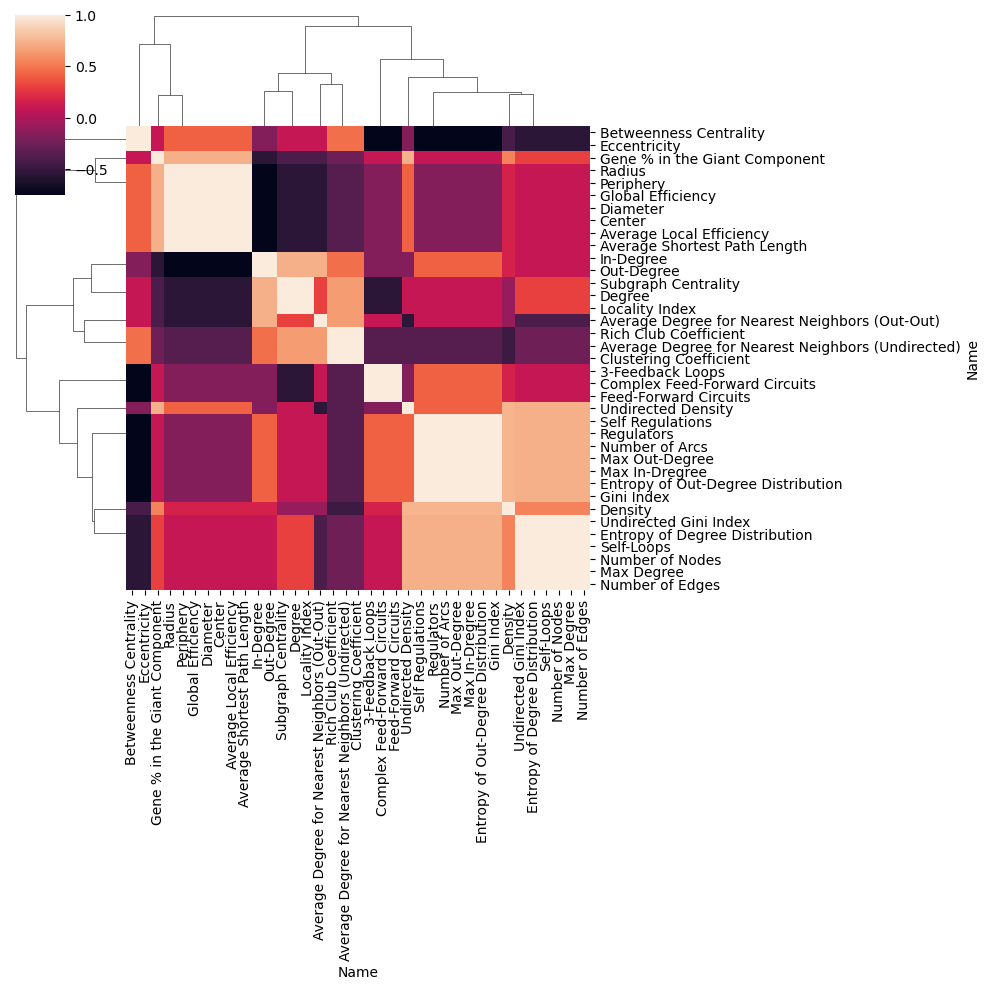

In [17]:
heatmap_df = properties_df.replace(False, 0)
heatmap_df = heatmap_df.replace(True, 1)
heatmap_df = heatmap_df.set_index('Name')
foo = heatmap_df.T
buena = foo.corr()
cluster = sb.clustermap(buena)